# Analysis

## Part 1. The whole dataset

In [97]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("data/vk_photos_perm_enriched.full.csv")
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows from {DATA_PATH}, columns: {', '.join(df.columns)}")
df.head(3)

Loaded 6,731 rows from data/vk_photos_perm_enriched.full.csv, columns: photo_id, owner_id, album_id, post_id, post_url, image_url, related_photo_urls, hashtags, date_human, lat, long, poi_lat, poi_lon, distance_meters, poi_name, user_id, user_gender, user_age, user_city, user_city_id, user_kind, post_text, inside_poi_area, inside_poi_building, annotation_text_description, annotation_location_type, annotation_photo_type, annotation_is_advertisement, annotation_city_objects, annotation_city_activities, annotation_user_intent, annotation_has_building, annotation_has_synagogue, annotation_has_feor, annotation_has_other_building, annotation_confidence, model_version, model_timestamp


,photo_id,owner_id,album_id,post_id,post_url,image_url,related_photo_urls,hashtags,date_human,lat,...,annotation_city_objects,annotation_city_activities,annotation_user_intent,annotation_has_building,annotation_has_synagogue,annotation_has_feor,annotation_has_other_building,annotation_confidence,model_version,model_timestamp
0,456239657,-46008634,247407234,NaN,NaN,https://sun9-69.userapi.com/s/v1/ig1/L9PGrYd5I...,NaN,NaN,2017-10-10 12:11:46,58.008044,...,NaN,NaN,показать еду,False,False,False,False,0.82,gpt-5-nano,2025-11-23T20:21:50.746278+00:00
1,457314552,-43730800,301537621,NaN,NaN,https://sun9-85.userapi.com/s/v1/if2/3j24JQH0E...,NaN,NaN,2024-12-10 08:55:17,58.007618,...,NaN,NaN,показать товар,False,False,False,False,0.72,gpt-5-nano,2025-11-23T20:21:50.746356+00:00
2,457240340,-224421397,300940670,NaN,NaN,https://sun9-41.userapi.com/s/v1/ig2/jMEQj5Cqf...,NaN,NaN,2024-03-24 12:36:35,58.008604,...,"стол, дрели, деревянные заготовки, инструменты...",мастер-класс по столярке,показать процесс столярной работы вдвоём,False,False,False,False,0.75,gpt-5-nano,2025-11-23T20:21:50.746400+00:00


In [111]:
total = len(df)
print(f"Total rows: {total}")

# Photos by POI name and year
df["date"] = pd.to_datetime(df["date_human"])
df["year"] = df["date"].dt.year
df["poi_name"] = df["poi_name"].fillna("unknown")

Total rows: 6731


In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_poi_year_counts(df, name="Total photos"):
    poi_year_counts = df.groupby(["poi_name", "year"]).size().reset_index(name="count")
    plt.figure(figsize=(8, 4))
    sns.barplot(x="year", y="count", hue="poi_name", data=poi_year_counts)
    plt.title(f"{name} by POI name and year")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.legend(title="POI Name")

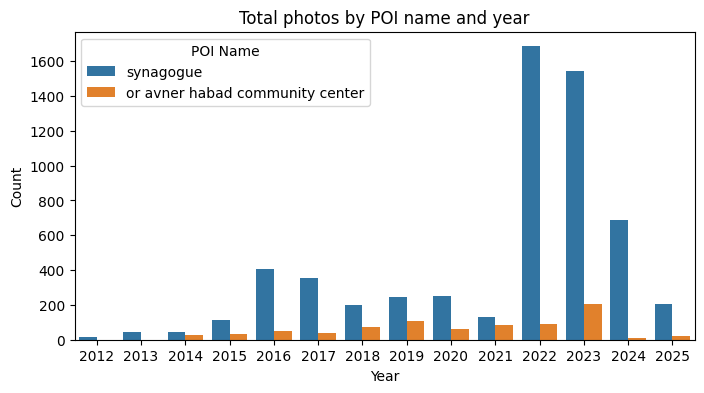

In [113]:
visualize_poi_year_counts(df)

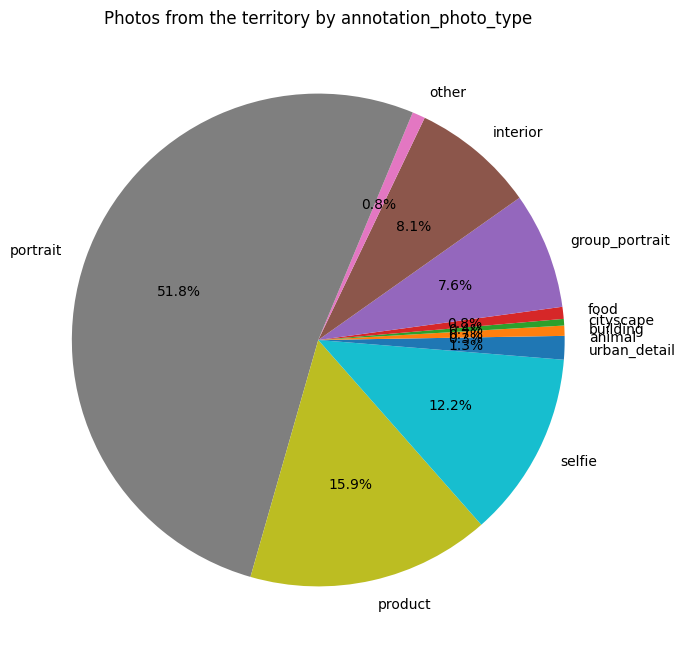

In [114]:
def visualize_photo_types(df, name="Photos from the territory"):
    grouped = df.groupby(["annotation_photo_type"]).size().reset_index(name="count")
    # a pie chart with annotation_photo_type count
    plt.figure(figsize=(8, 8))
    plt.pie(grouped["count"], labels=grouped["annotation_photo_type"], autopct="%1.1f%%")
    plt.title(f"{name} by annotation_photo_type")
    plt.show()

visualize_photo_types(df)


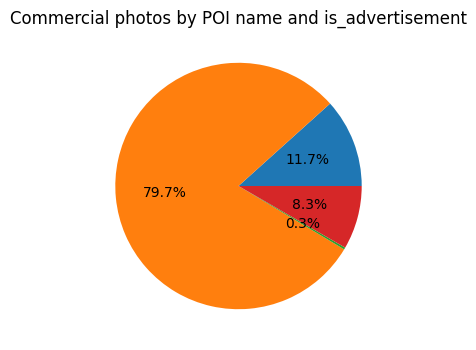

In [115]:
def visualize_commercial_photos_by_poi(df):
    grouped = df.groupby(["annotation_is_advertisement", "poi_name"]).size().reset_index(name="count")
    grouped["share"] = grouped["count"] / grouped.groupby("poi_name")["count"].transform("sum") * 100
    # a pie chart with share of the total by poi_name for each annotation_is_advertisement
    plt.figure(figsize=(8, 4))
    plt.pie(grouped["count"], autopct="%1.1f%%")
    plt.title(f"Commercial photos by POI name and is_advertisement")
    plt.show()

visualize_commercial_photos_by_poi(df)

### Part 1.1
Photos from the buildings territories. 

In [116]:
inside_building_mask = df["inside_poi_building"].fillna(False)
inside_df = df[inside_building_mask]
print(f"Photos from the buildings territories: {len(inside_df):,}")

Photos from the buildings territories: 377


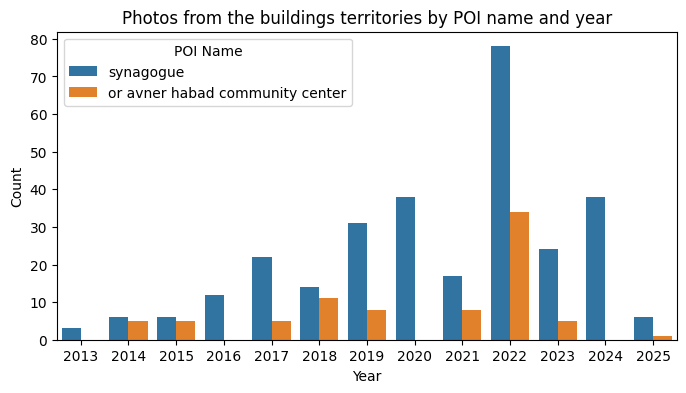

In [117]:
### Photos from the building 
visualize_poi_year_counts(inside_df, name="Photos from the buildings territories")

In [118]:
def visualize_poi_location_type(df, name="Photos from the territory"):
    grouped = df.groupby(["poi_name", "annotation_location_type"]).size().reset_index(name="count")
    grouped["share"] = grouped["count"] / grouped.groupby("poi_name")["count"].transform("sum") * 100
    # make two pie charts, one for each poi_name
    plt.figure(figsize=(8, 4))
    for i, poi_name in enumerate(grouped["poi_name"].unique()):
        poi_data = grouped[grouped["poi_name"] == poi_name]
        plt.subplot(1, 2, i + 1)
        plt.pie(poi_data["count"], labels=poi_data["annotation_location_type"], autopct="%1.1f%%")
        plt.title(f"{name} of {poi_name} by location type")
        plt.show()


/var/folders/yz/1n0b98zd7zqcxhyl8wl435h40000gn/T/ipykernel_78144/3962888877.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inside_df["annotation_location_type"] = inside_df["annotation_location_type"].fillna("unknown")


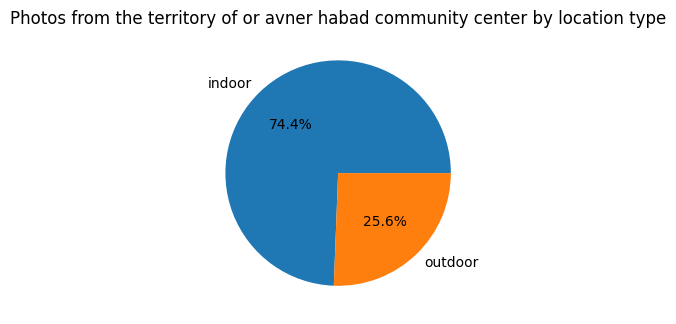

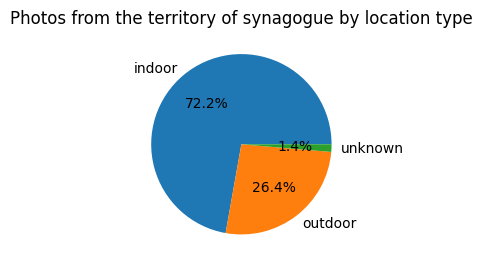

In [119]:
# Photos from the buildings territories by poi and annotation_location_type, share of the total by poi
inside_df["annotation_location_type"] = inside_df["annotation_location_type"].fillna("unknown") 
visualize_poi_location_type(inside_df)

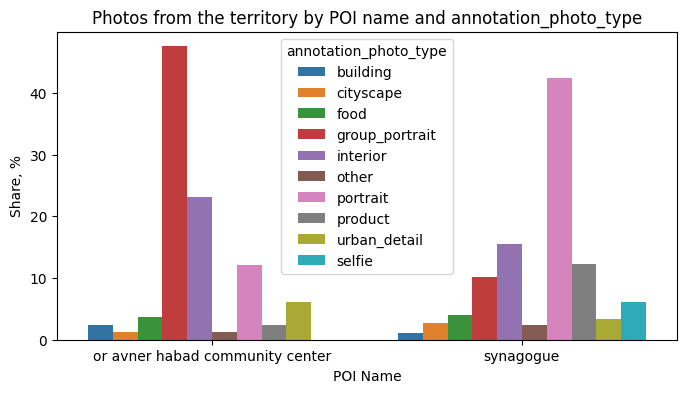

In [110]:
def visualize_poi_photo_type(df, name="Photos from the territory"):
    grouped = df.groupby(["poi_name", "annotation_photo_type"]).size().reset_index(name="count")
    grouped["share"] = grouped["count"] / grouped.groupby("poi_name")["count"].transform("sum") * 100
    # a bar chart with share of the total by poi_name for each annotation_photo_type
    plt.figure(figsize=(8, 4))
    sns.barplot(x="poi_name", y="share", hue="annotation_photo_type", data=grouped)
    plt.title(f"{name} by POI name and annotation_photo_type")
    plt.xlabel("POI Name")
    plt.ylabel("Share, %")
    plt.show()

visualize_poi_photo_type(inside_df)

In [ ]:
## Visualize photo_type change over time, using heatmap for each photo_type. Create separate graphs for each poi 



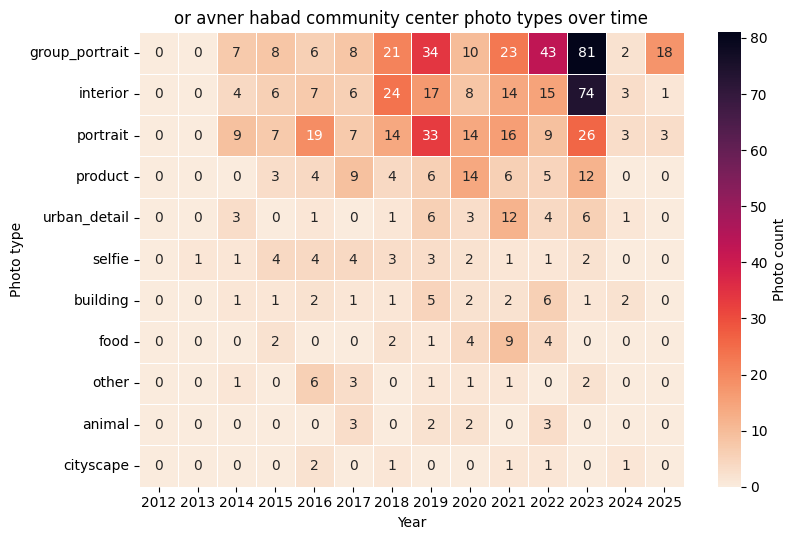

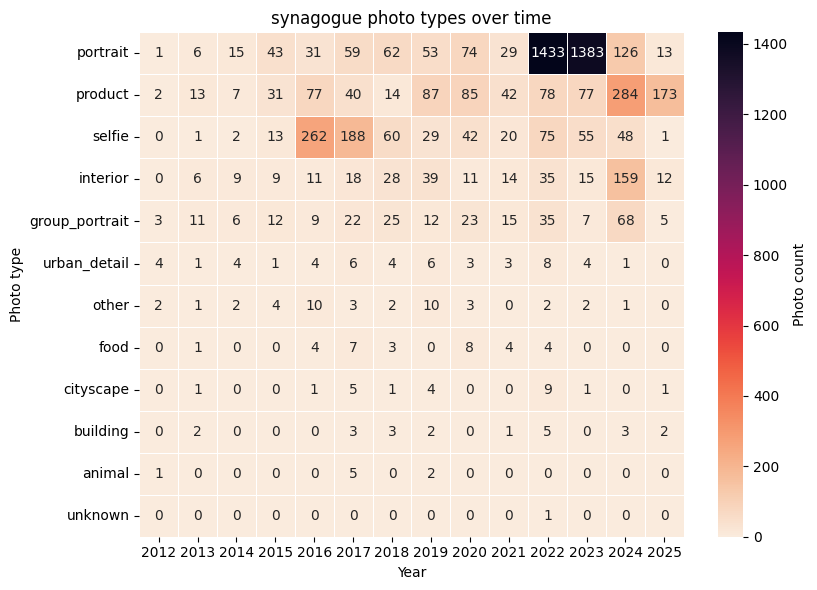

In [124]:
def plot_photo_type_heatmaps_by_poi(df: pd.DataFrame) -> None:
    """Draw one heatmap per POI showing how photo types change over time."""
    data = df.copy()

    if "year" not in data.columns:
        data["date"] = pd.to_datetime(data["date_human"])
        data["year"] = data["date"].dt.year

    data["poi_name"] = data["poi_name"].fillna("unknown")
    data["annotation_photo_type"] = data["annotation_photo_type"].fillna("unknown")

    years = sorted(y for y in data["year"].dropna().unique())
    if not years:
        print("No year information available for plotting")
        return

    for poi in sorted(data["poi_name"].unique()):
        poi_data = data[data["poi_name"] == poi]
        if poi_data.empty:
            continue

        pivot = (
            poi_data.pivot_table(
                index="annotation_photo_type",
                columns="year",
                values="photo_id",
                aggfunc="count",
                fill_value=0,
            )
            .reindex(columns=years, fill_value=0)
        )

        if pivot.empty:
            continue

        order = pivot.sum(axis=1).sort_values(ascending=False).index
        pivot = pivot.reindex(order)

        plt.figure(figsize=(max(6, 0.6 * len(years)), max(3, 0.5 * len(pivot.index))))
        sns.heatmap(
            pivot,
            cmap="rocket_r",
            linewidths=0.5,
            linecolor="white",
            annot=True,
            fmt="g",
            cbar_kws={"label": "Photo count"},
        )
        plt.title(f"{poi} photo types over time")
        plt.xlabel("Year")
        plt.ylabel("Photo type")
        plt.tight_layout()
        plt.show()


plot_photo_type_heatmaps_by_poi(df)


### Part 1.2
Photos from areas of visibility with building in it

In [120]:
# DATA_BUILDING_PATH = Path("data/vk_photos_perm_enriched.building_flags_applied.csv")
# buildings_df = pd.read_csv(DATA_BUILDING_PATH)


In [121]:
building_mask = df["annotation_has_building"].fillna(False) & (~df["inside_poi_building"].fillna(False))
buildings_df = df[building_mask]

print(f"Photos from areas of visibility with building in them: {len(buildings_df):,}")

Photos from areas of visibility with building in them: 1,048


In [122]:
buildings_df.head(3)

,photo_id,owner_id,album_id,post_id,post_url,image_url,related_photo_urls,hashtags,date_human,lat,...,annotation_user_intent,annotation_has_building,annotation_has_synagogue,annotation_has_feor,annotation_has_other_building,annotation_confidence,model_version,model_timestamp,date,year
4,457239798,-209485236,292620802,NaN,NaN,https://sun9-41.userapi.com/s/v1/ig2/W5UTizFcK...,NaN,NaN,2023-01-28 08:23:55,58.007308,...,показать интерьер с женщиной и праздничной обс...,True,False,False,False,0.71,gpt-5-nano,2025-11-23T20:21:50.746481+00:00,2023-01-28 08:23:55,2023
8,457240536,-224421397,301013678,NaN,NaN,https://sun9-18.userapi.com/s/v1/ig2/cfVvOfG_9...,NaN,NaN,2024-03-30 09:45:20,58.008604,...,позируют перед камерой,True,False,False,False,0.72,gpt-5-nano,2025-11-23T20:21:50.746653+00:00,2024-03-30 09:45:20,2024
9,457240685,-224421397,301013678,NaN,NaN,https://sun9-47.userapi.com/s/v1/ig2/jG7xotbNK...,NaN,NaN,2024-03-30 10:44:16,58.008604,...,показать мастер-класс по деревообработке,True,False,False,False,0.78,gpt-5-nano,2025-11-23T20:21:50.746676+00:00,2024-03-30 10:44:16,2024


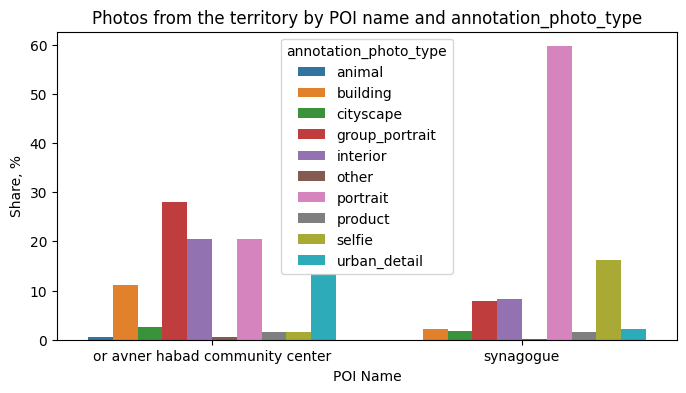

In [123]:
visualize_poi_photo_type(buildings_df)

## Part 2. 
Trying to clusterize photographs

In [22]:
! pip install scikit-learn

  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 14.7 MB/s eta 0:00:0000:0100:01
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 11.3 MB/s eta 0:00:0000:0100:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 25.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [26]:
cluster_df = df.copy()
cluster_df["annotation_text_description"] = cluster_df["annotation_text_description"].fillna("")

In [94]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# convert text to TF–IDF vectors
vectorizer = TfidfVectorizer(
    stop_words=None,
    min_df=2,                # tweak for your data size
    max_features=5000        # guard against sparse noise
)
tfidf = vectorizer.fit_transform(cluster_df["annotation_text_description"])

k = 15
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
cluster_df["cluster"] = kmeans.fit_predict(tfidf)

print(cluster_df[["photo_id", "cluster", "annotation_text_description"]])

       photo_id  cluster                        annotation_text_description
0     423419286        5    Ожерелье из жемчуга на белом фоне, крупный план
1     457250512        4  Женщина позирует внутри комнаты: в тёмном пидж...
2     403011859        1  Женщина в клетчатом пальто делает селфи в зерк...
3     457239063        6  Интерьер ночного заведения: синяя/фиолетовая п...
4     457257194        2  Женщина в интерьере перед белой стеной, позиру...
...         ...      ...                                                ...
5800  457257552        4  Женщина в белой майке и черных спортивных шорт...
5801  457247686        6  ночная уличная сцена с висящими красными фонар...
5802  457259864        6  Человек в черной куртке и шапке позирует на от...
5803  457256811       14  Полноразмерная портретная фотография женщины в...
5804  456239028        6  Серая балаклава/шапка балаклава с прорезью для...

[5805 rows x 3 columns]


In [47]:
cluster_df.groupby("cluster").size().reset_index(name="count")

,cluster,count
0,0,236
1,1,100
2,2,170
3,3,836
4,4,186
5,5,95
6,6,287
7,7,118
8,8,115
9,9,108


In [96]:
cluster_df[cluster_df["cluster"] == 0].annotation_text_description

15      Серое меховое пальто на вешалке на фоне деревя...
23      Полосатый свитшот с горизонтальными полосами р...
47      Хаки куртка-парка на вешалке перед горизонталь...
52      Белый пуховый жилет на вешалке висит перед бел...
55      Две кофты на вешалках висят перед деревянной с...
                              ...                        
5629    Зеленый свитшот на вешалке перед белыми жалюзи...
5666      Черная пуховая куртка висит на деревянной стене
5695    Серый пуховик на плечиках перед деревянной стеной
5742    Худи разных цветов на вешалке в магазине рядом...
5747    Черные спортивные штаны на вешалке перед белой...
Name: annotation_text_description, Length: 276, dtype: object